<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/movenet_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Использование MoveNet: https://www.tensorflow.org/hub/tutorials/movenet?hl=ru

Оригинальный эксперимент: https://dl.acm.org/doi/epdf/10.1145/3663976.3664014

In [ ]:
! pip install -q imageio
! pip install -q git+https://github.com/tensorflow/docs
! pip install matplotlib==3.9.0

In [2]:
import tensorflow as tf
import tensorflow_hub as tf_hub
import numpy as np
import cv2
import imageio
import os
from tensorflow_docs.vis import embed
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection

from tensorflow.keras.losses import MeanAbsoluteError
import tensorflow.keras as keras
from tensorflow.keras import layers, models, applications
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

movenet_lightning

In [3]:
model_lightning = tf_hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
size_lightning = 192

In [ ]:
signature = model_lightning.signatures["serving_default"]
print(signature.structured_outputs.keys())
print(model_lightning.signatures.keys())

In [ ]:
# получаю предсказания модели на фотографии
def detection(image_path, model, input_size):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image)
  img = tf.expand_dims(image, axis=0)
  resized_img = tf.image.resize_with_pad(img, input_size, input_size)
  img_np = resized_img.numpy().astype(np.int32)
  output = model.signatures["serving_default"](tf.constant(img_np))
  keypoints = output['output_0'].numpy()
  return keypoints

input_image_path = '/content/frame_0016.jpg'
keypoints = detection(input_image_path, model_lightning, size_lightning)
# print(resized_img.shape)
print(keypoints[0][0])

In [ ]:
points = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder']
# цифры в connections - индексы в points, нос связан с глазами (0, 1) и (0, 2) и тд.
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (0, 5), (0, 6), (5, 6)]
def make_skeleton(keypoints, image, image_height, image_width):
  # num_people = keypoints.shape[0]
  fig, ax = plt.subplots(figsize=(12 * (float(image_width) / image_height), 12))
  scat = ax.scatter([], [], s=60, color='#FF1333', zorder=3)
  background_image = ax.imshow(image)
  arr_edges = []
  for i in range(1):
    seven_points = keypoints[i][0][:7]
    # print(seven_points)
    x = [a[1] for a in seven_points]
    y = [a[0] for a in seven_points]
    arr_coordinates_x = [float(coordinate) * image_width for coordinate in x]
    arr_coordinates_y = [float(coordinate) * image_height for coordinate in y]
  arr_coord_point_1 = []
  arr_coord_point_2 = []
  for i in range(len(connections)):
    point_1 = connections[i][0]
    point_2 = connections[i][1]
    coord_point_1 = (round(arr_coordinates_x[point_1], 4), round(arr_coordinates_y[point_1], 4)) # кортеж координат первой точки
    coord_point_2 = (round(arr_coordinates_x[point_2], 4), round(arr_coordinates_y[point_2], 4)) # кортеж координат второй точки
    arr_coord_point_1.append(coord_point_1)
    arr_coord_point_2.append(coord_point_2)

  # print(arr_coord_point_1)
  # print(arr_coord_point_2)
  coord_points = np.stack([arr_coord_point_1, arr_coord_point_2], axis=1)
  coord_concat = np.concatenate(coord_points, axis=0)

  lines = np.array([arr_coord_point_1, arr_coord_point_2])
  merged_lines = np.stack(lines, axis=1)
  line_collection = LineCollection([], linewidths=(4), linestyle='solid')
  ax.add_collection(line_collection)
  line_collection.set_segments(merged_lines)
  scat.set_offsets(coord_concat)


# тестирование функции:
def resize_image(img_path, model_size):
  input_image = tf.io.read_file(img_path)
  input_image = tf.image.decode_jpeg(input_image)
  # print(input_image.shape)
  picture = tf.expand_dims(input_image, axis=0)
  picture = tf.image.resize_with_pad(picture, model_size, model_size)
  # print(picture.shape)
  display_pic = tf.expand_dims(input_image, axis=0)
  display_pic = tf.cast(tf.image.resize_with_pad(display_pic, 1280, 1280), dtype=tf.int32)
  result_image = np.squeeze(display_pic.numpy(), axis=0)
  # print(result_image.shape)
  image_height, image_width, a = result_image.shape
  return result_image, image_height, image_width

result_image, image_height, image_width = resize_image(input_image_path, size_lightning)
make_skeleton(keypoints, result_image, image_height, image_width)


In [ ]:
# визуальная проверка качества вывода модели
def check_dataset_skeletons(dataset_path):
  for x in os.listdir(dataset_path):
    photo_path = dataset_path + '/' + x
    kpts = detection(photo_path, model_lightning, size_lightning)
    # print(kpts)
    result_image, image_height, image_width = resize_image(photo_path, size_lightning)
    make_skeleton(kpts, result_image, image_height, image_width)
check_dataset_skeletons("/content/drive/MyDrive/sitting_pose_dataset")

Проверим исходные модели movenet_lightning на качество на датасете с сидячими людьми (80 фотографий).

Метрика PCK:

In [7]:
## COCO FORMAT:
# 0 - nose,
# 1 - neck,
# 2 - right_shoulder,
# 3 - right_elbow,
# 4 - right_wrist,
# 5 - left_shoulder,
# 6 - left_elbow,
# 7 - left_wrist,
# 8 - right_hip,
# 9 - right_knee,
# 10 - right_ankle,
# 11 - left_hip,
# 12 - left_knee,
# 13 - left_ankle,
# 14 - right_eye,
# 15 - left_eye,
# 16 - right_ear,
# 17 - left_ear

# MoveNet FORMAT: ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder']

# проверка исходной модели на качество в разрезе нашей задачи:
import os
import json

val_dataset_path = '/content/drive/MyDrive/sitting_pose_dataset/'
val_dataset_frames = []
sorted_dataset = []
for x in os.listdir(val_dataset_path):
  val_dataset_frames.append(x)
sorted_dataset = sorted(val_dataset_frames)

def make_predictions(model, model_size, dataset_path, dataset): # подаю датасет, получаю точки от модели
  pairs_xy = []
  num = 0
  for photo in dataset:
    image_path = dataset_path + str(photo)
    photo_keypoints = detection(image_path, model, model_size)
    input_image = tf.io.read_file(image_path)
    input_image = tf.image.decode_jpeg(input_image)
    height, width, _ = input_image.shape
    if (len(photo_keypoints.shape) == 4):
      resized_x = photo_keypoints[0, 0, :, 1] * width
      resized_y = photo_keypoints[0, 0, :, 0] * height
    elif (len(photo_keypoints.shape) == 3):
      print(photo_keypoints)
      print(photo_keypoints[0, :, 0])
      print(photo_keypoints[0, :, 1])
      resized_x = photo_keypoints[0, :, 1] * width
      resized_y = photo_keypoints[0, :, 0] * height
    for i in range(0, 7):
      pairs_xy.append((resized_x[i], resized_y[i]))
    num += 1
  return (pairs_xy)

def extract_ideal_annotations(true_annotations): # подаю ground_truth аннотации из файла, получаю списки
                                                 # нужных точек
  with open(true_annotations, "r", encoding="utf-8") as ground_truth:
    info = json.load(ground_truth)
  arr = []
  extracted_keypoints = []
  for x in info.get("annotations"):
    arr.append(x.get("keypoints"))
  for i in range(len(arr)):
    clean_arr = []
    if str(arr[i]) != "None":
      tmp = arr[i]
      clean_arr.append([tmp[0], tmp[1]]) # tmp[2],  nose
      clean_arr.append([tmp[45], tmp[46]]) # tmp[47], left_eye
      clean_arr.append([tmp[42], tmp[43]]) # tmp[44], right_eye
      clean_arr.append([tmp[51], tmp[52]]) # tmp[53], left_ear
      clean_arr.append([tmp[48], tmp[49]]) # tmp[50], right_ear
      clean_arr.append([tmp[15], tmp[16]]) # tmp[17], left_shoulder
      clean_arr.append([tmp[6], tmp[7]]) # tmp[8]] right_shoulder
      extracted_keypoints.append(clean_arr)
  return extracted_keypoints

In [ ]:
print(sorted_dataset)

In [9]:
# получаем предсказания на всём валидационном датасете
prediction_pairs_xy = make_predictions(model_lightning, size_lightning, val_dataset_path, sorted_dataset)
# print(*[f"{np.float32(x)}, \n" for x in prediction_pairs_xy])

In [10]:
# получаем идеальные точки разметки для датасета на 80
extracted_ideal_keypoints80 = extract_ideal_annotations("/content/result_TRUE80.json")
ideal_keypoints_list80 = []
for x in extracted_ideal_keypoints80:
  for pair in x:
    ideal_keypoints_list80.append(pair)
# print(*[f"{x},\n" for x in extracted_ideal_keypoints80])

In [11]:
# получаем идеальные точки разметки для датасета на 150
extracted_ideal_keypoints150 = extract_ideal_annotations("/content/result_TRUE150.json")
ideal_keypoints_list150 = []
for x in extracted_ideal_keypoints150:
  for pair in x:
    ideal_keypoints_list150.append(pair)

In [ ]:
# пример того, как выглядит скелет на фотографии 720 * 1280 с координатами из идеальной разметки
def draw_image_ex(pic, image_height, image_width):
  fig, ax = plt.subplots(figsize=(12 * (float(image_width) / image_height), 12))
  scat = ax.scatter([], [], s=60, color='#FF1333', zorder=3)
  background_image = ax.imshow(image)
  arr_edges = []
  x = [610, 687, 565, 781, 504, 878, 371]
  y = [221, 187, 189, 254, 262, 480, 469]
  arr_coordinates_x = [float(coordinate) for coordinate in x]
  arr_coordinates_y = [float(coordinate) for coordinate in y]
  arr_coord_point_1 = []
  arr_coord_point_2 = []
  for i in range(len(connections)):
    point_1 = connections[i][0]
    point_2 = connections[i][1]
    coord_point_1 = (round(arr_coordinates_x[point_1], 4), round(arr_coordinates_y[point_1], 4)) # кортеж координат первой точки
    coord_point_2 = (round(arr_coordinates_x[point_2], 4), round(arr_coordinates_y[point_2], 4)) # кортеж координат второй точки
    arr_coord_point_1.append(coord_point_1)
    arr_coord_point_2.append(coord_point_2)

  print(arr_coord_point_1)
  print(arr_coord_point_2)
  coord_points = np.stack([arr_coord_point_1, arr_coord_point_2], axis=1)
  coord_concat = np.concatenate(coord_points, axis=0)

  lines = np.array([arr_coord_point_1, arr_coord_point_2])
  merged_lines = np.stack(lines, axis=1)
  line_collection = LineCollection([], linewidths=(4), linestyle='solid')
  ax.add_collection(line_collection)
  line_collection.set_segments(merged_lines)
  scat.set_offsets(coord_concat)

image = tf.io.read_file("/content/frame_0016.jpg")
image = tf.image.decode_jpeg(image)
print(image.shape)
image_height, image_width, alpha = image.shape
draw_image_ex(image, image_height, image_width)

In [13]:
def percentage_of_correct_keypoints(predictions, ground_truth, alpha): # метрика PCK
  num_keypoints = 7
  sum = 0
  formula = 0
  arr_left_ear = []
  arr_right_shoulder = []
  output = []
  for i in range(3, len(ground_truth), 7):
    arr_left_ear.append(ground_truth[i])
  for i in range(6, len(ground_truth), 7):
    arr_right_shoulder.append(ground_truth[i])
  for i in range(len(predictions)): # 560
    if ((i % 7 == 0) or (i == 0)):
      threshold = ((arr_left_ear[int(i / 7)][0] - arr_right_shoulder[int(i / 7)][0]) ** 2 +
       (arr_left_ear[int(i / 7)][1] - arr_right_shoulder[int(i / 7)][1]) ** 2) ** 0.5
    x_ideal = ground_truth[i][0]
    y_ideal = ground_truth[i][1]
    x_predict = predictions[i][0]
    y_predict = predictions[i][1]
    distance = ((x_ideal - x_predict) ** 2 + (y_ideal - y_predict) ** 2) ** 0.5
    if (distance < threshold * alpha):
      sum += 1
  return (sum / len(predictions))

In [14]:
alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
percents_lightning = []
for a in alpha:
  percent = percentage_of_correct_keypoints(prediction_pairs_xy, ideal_keypoints_list80, a)
  percents_lightning.append(round(percent * 100, 3))
print(percents_lightning)

[41.964, 72.321, 87.143, 88.929, 90.179, 90.357, 90.357, 90.357, 90.714, 91.964]


movenet_thunder

In [15]:
model_thunder = tf_hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
size_thunder = 256

In [16]:
keypoints_thunder = detection(input_image_path, model_thunder, size_thunder)
print(keypoints_thunder)

[[[[0.40029    0.48182264 0.72276425]
   [0.3590008  0.53495437 0.7938941 ]
   [0.3562095  0.4411889  0.7479636 ]
   [0.41937786 0.59797466 0.72946984]
   [0.40355885 0.39569196 0.7407135 ]
   [0.5942347  0.69789803 0.7771789 ]
   [0.58931077 0.29174954 0.58016175]
   [0.7903517  0.8208426  0.18874325]
   [0.7806467  0.15018962 0.17652543]
   [0.7641541  0.7171139  0.05334989]
   [0.7159771  0.26672414 0.00680057]
   [0.86564094 0.6440654  0.07338429]
   [0.8484899  0.33019775 0.07567261]
   [0.69395    0.75088716 0.06460295]
   [0.66115344 0.4414535  0.02669561]
   [0.72207433 0.6300786  0.02045548]
   [0.722631   0.53105074 0.04207145]]]]


In [ ]:
input_image = tf.io.read_file(input_image_path)
input_image = tf.image.decode_jpeg(input_image)
# print(input_image.shape)
picture = tf.expand_dims(input_image, axis=0)
picture = tf.image.resize_with_pad(picture, size_thunder, size_thunder)
# print(picture.shape)
display_pic = tf.expand_dims(input_image, axis=0)
display_pic = tf.cast(tf.image.resize_with_pad(display_pic, 1280, 1280), dtype=tf.int32)
result_image = np.squeeze(display_pic.numpy(), axis=0)
image_height, image_width, a = result_image.shape
# print(image_height, image_width)
make_skeleton(keypoints_thunder, result_image, image_height, image_width)

In [18]:
prediction_pairs_xy_thunder = make_predictions(model_thunder, size_thunder, val_dataset_path, sorted_dataset)
# print(*[f"{np.float32(x)}, \n" for x in prediction_pairs_xy_thunder])

In [19]:
alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
percents_thunder = []
for a in alpha:
  percent = percentage_of_correct_keypoints(prediction_pairs_xy_thunder, ideal_keypoints_list80, a)
  percents_thunder.append(round(percent * 100, 3))
print(percents_thunder)

[44.107, 74.107, 88.036, 90.179, 90.179, 90.179, 90.357, 90.357, 90.714, 92.321]


Сравнение метрик качества двух исходных моделей - lightning и thunder

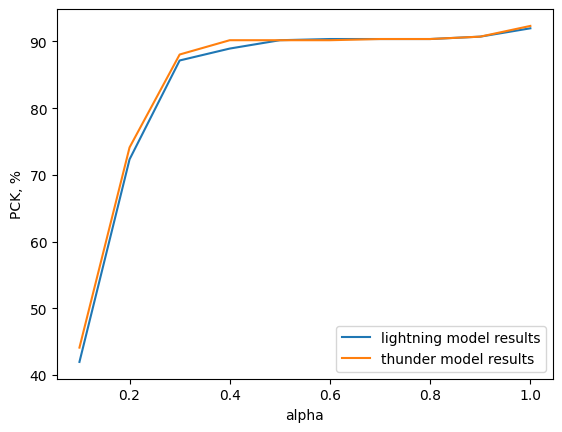

In [20]:
plt.plot(alpha, percents_lightning, label="lightning model results")
plt.plot(alpha, percents_thunder, label="thunder model results")
plt.xlabel('alpha')
plt.ylabel('PCK, %')
plt.legend()
plt.show()

Как видно, модель thunder немного лучше предсказывает ключевые точки на теле сидячего человека, как и было объявлено авторами MoveNet (изначально предполагается, что thunder делает более качественные предсказания).

Классификатор MLP на scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

def metrics_calculation(true, pred):
  metric = {'Accuracy': round(metrics.accuracy_score(true, pred), 3)}
  print("Accuracy: ", metric['Accuracy'])
  return metric

In [ ]:
# нужно получить предсказания (x, y) для каждой фотографии - data
# название класса - target
X = [] # признаки
y = [] # классы

categories = ['head_left', 'head_right', 'correct']
mlp_dataset_path = '/content/drive/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_MLP_dataset/'

mlp_head_left_frames = []
mlp_head_right_frames = []

sorted_mlp_head_left = []
sorted_mlp_head_right = []

path_0 = mlp_dataset_path + categories[0] + '/'
path_1 = mlp_dataset_path + categories[1] + '/'

for x in os.listdir(path_0):
  y.append(0)
  mlp_head_left_frames.append(x)

for x in os.listdir(path_1):
  y.append(1)
  mlp_head_right_frames.append(x)

sorted_mlp_head_left = sorted(mlp_head_left_frames)
sorted_mlp_head_right = sorted(mlp_head_right_frames)

tmp_X = [] # временно, потом избавлюсь от np.float32

pred_head_left = make_predictions(model_lightning, size_lightning, path_0, sorted_mlp_head_left) # признаки
for i in range(0, len(pred_head_left), 7):
  tmp_X.append(pred_head_left[i:i+7])

pred_head_right = make_predictions(model_lightning, size_lightning, path_1, sorted_mlp_head_right) # признаки
for i in range(0, len(pred_head_right), 7):
  tmp_X.append(pred_head_right[i:i+7])


print("Голова влево: ", pred_head_left)
print("Голова вправо: ", pred_head_right)

In [ ]:
mlp_head_correct_frames = []

sorted_mlp_correct = []

path_2 = mlp_dataset_path + categories[2] + '/'

for x in os.listdir(path_2):
  y.append(2)
  mlp_head_correct_frames.append(x)

sorted_mlp_correct = sorted(mlp_head_correct_frames)

pred_correct = make_predictions(model_lightning, size_lightning, path_2, sorted_mlp_correct) # признаки
for i in range(0, len(pred_correct), 7):
  tmp_X.append(pred_correct[i:i+7])

print("Правильно: ", pred_correct)

In [ ]:
X = []
arr = [[tuple(float(a) for a in x) for x in line] for line in tmp_X]
for pairs in arr:
  flat = []
  for x_coord, y_coord in pairs:
    flat.extend([x_coord, y_coord])
  X.append(flat)
print(X)
print(y)

In [116]:
print(len(X))

567


In [118]:
print(len(sorted_mlp_head_left) + len(sorted_mlp_head_right) + len(sorted_mlp_correct))

567


In [119]:
print(np.array(X).shape)

(567, 14)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='relu',
    alpha=0.1,
    solver='adam',
    max_iter=1000,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    shuffle=True,
    verbose=True,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)
metrics_calculation(y_test, y_pred)

# categories = ['correct', 'head_left', 'head_right', 'body_left', 'body_right', 'too_close', 'tilt_back', 'bend_over']

In [170]:
! cd /content/examples/ && rm -rf .ipynb_checkpoints

In [171]:
# left - 0, right - 1, correct - 2
path_example = '/content/examples/'
ex = []
for x in os.listdir(path_example):
  ex.append(x)
print(ex)
new_photo = make_predictions(model_lightning, size_lightning, path_example, ex)

['5538802818675508338e84a462c1acc7b5c6c71ed02_b.jpg']


In [ ]:
print(new_photo)

In [ ]:
X_new = []
arr_new = [tuple(float(a) for a in x) for x in new_photo]
for x_coord, y_coord in arr_new:
  X_new.append(x_coord)
  X_new.append(y_coord)
print(X_new)
print(len(X_new))

In [181]:
features = np.array(X_new).reshape(1, -1)
X_new_scaled = scaler.transform(features)
pred_new = mlp.predict(X_new_scaled)
prob_new = mlp.predict_proba(X_new_scaled)
num = pred_new[0]
# print(num)
print(categories[num])
for line in prob_new:
  for p in line:
    print(f"{p:.2f}%")

correct
0.00%
0.15%
0.85%
